<h2>Necessary Libraries</h2>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

<h2>Data Generation</h2>

Enter your ID

In [ ]:
student_id = input("Enter your ID: ") #Type your ID after running this cell and then press Enter

Enter your ID: 230042143


In [ ]:
# ---- Convert ID to seed ----
seed = sum(ord(c) for c in student_id)
np.random.seed(seed)

# ---- Generate a and b from ID ----
a = (seed % 10) / 2 + 0.5      # slope between ~0.5 and 5
b = (seed % 20) - 10           # intercept between -10 and 10

# ---- Generate 45 normal points ----
x_normal = np.random.uniform(0, 10, 45)
noise = np.random.normal(0, 1.5, 45)
y_normal = a * x_normal + b + noise

# ---- Generate 5 outliers ----
x_out = np.random.uniform(0, 10, 5)
y_out = np.random.uniform(-20, 20, 5)

# ---- Combine points ----
x = np.concatenate([x_normal, x_out])
y = np.concatenate([y_normal, y_out])

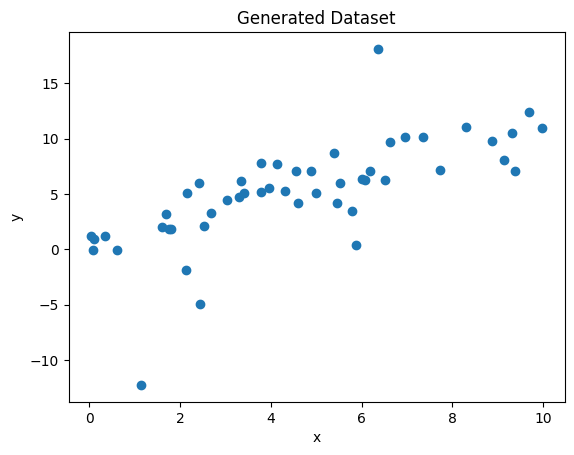

In [ ]:
# ---- Plot ----
plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated Dataset")
plt.show()

<h2>Problem Statement </h2>
Let the data generated above represent the number of weeks spent (x) and the level of regret for not taking the Linear Algebra course seriously (y). Your task is to determine the following.

In [ ]:
A = np.column_stack((x, np.ones(len(x))))
b = y

Complete the expression

In [ ]:
x_hat = np.linalg.inv(A.T @ A) @ A.T @ b

In [ ]:
a_hat = x_hat[0]
b_hat = x_hat[1]

In [ ]:
# ---- Predicted values ---- (incomplete)
y_hat = A @ x_hat

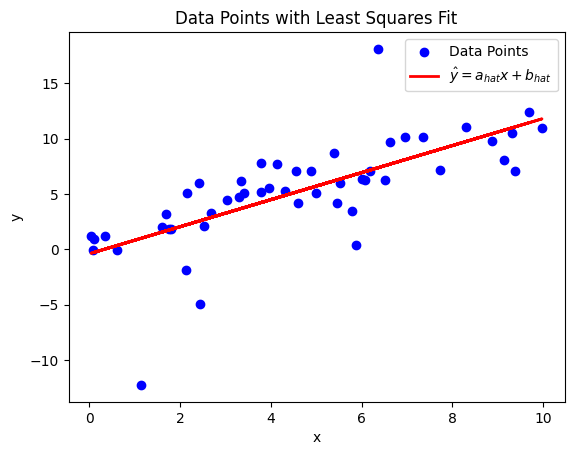

In [ ]:
# ---- Plot ----
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, y_hat, color='red', label=r'$\hat{y} = a_{hat} x + b_{hat}$', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Points with Least Squares Fit')
plt.legend()
plt.show()

In [ ]:
# Errors (residuals)
errors = y - y_hat

# Mean Squared Error
mse = np.mean(errors**2)

# Print results
print("Errors (y - y_hat) for all points:")
print(errors)
print(f"\nMean Squared Error (MSE) = {mse:.4f}")

Errors (y - y_hat) for all points:
[ -1.84147895   1.9965225    2.53904901  -0.60181371   0.38666834
   1.19337508  -0.6136814   -0.55781996  -3.191564    -0.8699758
   1.20622893   1.49073684  -2.66368697   3.59696061   1.59047209
   3.45531223   0.3963781   -0.36185683   1.11276469  -1.06250349
   2.85139687   0.4954941   -0.62685321  -1.29314209   1.11354587
  -0.46835459   2.47293243  -0.72100269   1.1877883    1.27757171
  -0.04948936   1.56235867   2.02028925  -2.10486191   1.2853209
   0.06477408   0.93433875   0.9987183    0.23936761  -0.44818466
   3.06368266   1.88645687  -3.9605081    0.09489988   1.46979693
  -6.41051268  -4.05017631  -7.55472267  10.73118141 -13.26219365]

Mean Squared Error (MSE) = 10.8192


<h2>Determine Outliers</h2>

Outliers are data points that do not follow the general pattern of the data. Try to identify these outliers, exclude them from your calculations, and observe whether removing them reduces the error.

Write your outlier finding algorithm here

In [ ]:
residuals = [yi - (a_hat * xi + b_hat) for xi, yi in zip(x, y)]

In [ ]:
std = np.std(residuals)


In [ ]:
outliers = []

# Separate outliers and regular points
regular_x = []
regular_y = []

for xi, yi in zip(x, y):
    error = yi - (a_hat * xi + b_hat)
    if abs(error) > 2 * std: # Perform something here
        print(error)
        outliers.append((xi, yi))  # append as tuple
    else:
        regular_x.append(xi)
        regular_y.append(yi)

# Convert outliers to separate lists for plotting
if outliers:  # check if there are any outliers
    outlier_x, outlier_y = zip(*outliers)
else:
    outlier_x, outlier_y = [], []

-7.554722674578034
10.73118140564978
-13.262193645430997


Plot Outliers

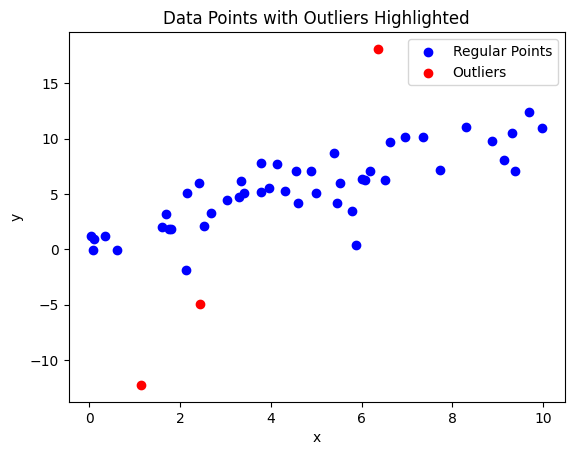

In [ ]:
plt.scatter(regular_x, regular_y, color='blue', label='Regular Points')
plt.scatter(outlier_x, outlier_y, color='red', label='Outliers')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Data Points with Outliers Highlighted')
plt.legend()
plt.show()

In [ ]:
# Convert to numpy arrays
x_reg = np.array(regular_x)
y_reg = np.array(regular_y)

# ---- Least Squares Fit on regular points ----
A_clean = np.column_stack((x_reg, np.ones(len(x_reg))))  # design matrix
theta_clean = np.linalg.inv(A_clean.T @ A_clean) @ A_clean.T @ y_reg
a_hat_clean, b_hat_clean = theta_clean

# ---- Predicted values ----
y_hat_clean = A_clean @ theta_clean

# ---- Calculate errors and MSE ----
errors_clean = y_reg - y_hat_clean
mse_clean = np.mean(errors_clean**2)

print("Fitted parameters (after removing outliers):")
print(f"a_hat = {a_hat_clean:.4f}, b_hat = {b_hat_clean:.4f}")
print(f"\nMean Squared Error (MSE) = {mse_clean:.4f}")

Fitted parameters (after removing outliers):
a_hat = 0.9945, b_hat = 0.8728

Mean Squared Error (MSE) = 3.6623


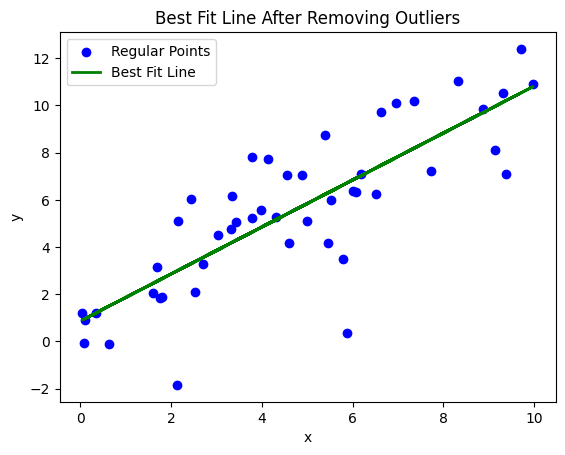

In [ ]:
# ---- Plot ----
plt.scatter(x_reg, y_reg, color='blue', label='Regular Points')
plt.plot(x_reg, y_hat_clean, color='green', label=r'Best Fit Line', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Best Fit Line After Removing Outliers')
plt.legend()
plt.show()

<h2>Something Better?</h2>

In [ ]:
Now that you’ve mastered fitting points to a straight line, try fitting the same data to a quadratic curve. Does the error decrease in this case?

Object `case` not found.


### Fitting to a Quadratic Curve

In [ ]:
x_reg_sq = x_reg**2
A_quad = np.column_stack((x_reg_sq, x_reg, np.ones(len(x_reg))))

theta_quad = np.linalg.inv(A_quad.T @ A_quad) @ A_quad.T @ y_reg

a_quad = theta_quad[0]
b_quad = theta_quad[1]
c_quad = theta_quad[2]

print("Fitted parameters for quadratic curve:")
print(f"a_quad = {a_quad:.4f}, b_quad = {b_quad:.4f}, c_quad = {c_quad:.4f}")

Fitted parameters for quadratic curve:
a_quad = -0.0221, b_quad = 1.2115, c_quad = 0.5099


In [ ]:
y_hat_quad = A_quad @ theta_quad

errors_quad = y_reg - y_hat_quad
mse_quad = np.mean(errors_quad**2)

print(f"\nMean Squared Error (MSE) for quadratic fit = {mse_quad:.4f}")
print(f"Mean Squared Error (MSE) for linear fit = {mse_clean:.4f}")

if mse_quad < mse_clean:
    print("The error decreased with the quadratic fit.")
else:
    print("The error did not decrease with the quadratic fit (or stayed the same).")


Mean Squared Error (MSE) for quadratic fit = 3.6301
Mean Squared Error (MSE) for linear fit = 3.6623
The error decreased with the quadratic fit.


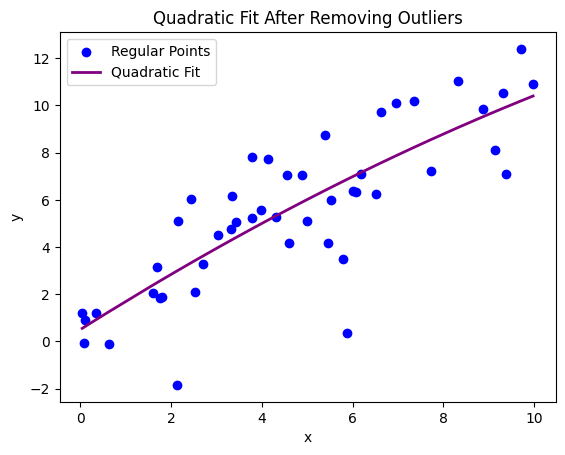

In [ ]:
plt.scatter(x_reg, y_reg, color='blue', label='Regular Points')

# Sort x_reg for plotting a smooth curve
sorted_indices = np.argsort(x_reg)
x_reg_sorted = x_reg[sorted_indices]
y_hat_quad_sorted = y_hat_quad[sorted_indices]

plt.plot(x_reg_sorted, y_hat_quad_sorted, color='purple', label=r'Quadratic Fit', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Quadratic Fit After Removing Outliers')
plt.legend()
plt.show()